## **Zadanie 1.**

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
def f(x, y):
    return 1 / np.sqrt(x + 3*y)

def grad_f(x, y):
    dfdx = -0.5 * (x + 3*y) ** (-3/2)
    dfdy = -1.5 * (x + 3*y) ** (-3/2)
    return np.array([dfdx, dfdy])

def gradient_descent(start_x=1, start_y=1, learning_rate=20, epochs=200):
    x = start_x
    y = start_y

    x_history = [x]
    y_history = [y]
    f_history = [f(x, y)]

    for i in range(epochs):
        grad = grad_f(x, y)

        x = x - learning_rate * grad[0]
        y = y - learning_rate * grad[1]

        x = np.clip(x, 1, 10)
        y = np.clip(y, 1, 10)

        x_history.append(x)
        y_history.append(y)
        f_history.append(f(x, y))

        if x == 10 and y == 10:
            break

    return np.array(x_history), np.array(y_history), np.array(f_history)

In [32]:
x_history, y_history, f_history = gradient_descent(
    start_x=1,
    start_y=1,
    learning_rate=20,
    epochs=200
)

print("Minimum znalezione metodą gradientu:")
print("x =", x_history[-1])
print("y =", y_history[-1])
print("f(x, y) =", f_history[-1])

print("\nDokładna wartość minimalna:")
print("f(10, 10) =", f(10, 10))

Minimum znalezione metodą gradientu:
x = 10.0
y = 10.0
f(x, y) = 0.15811388300841897

Dokładna wartość minimalna:
f(10, 10) = 0.15811388300841897


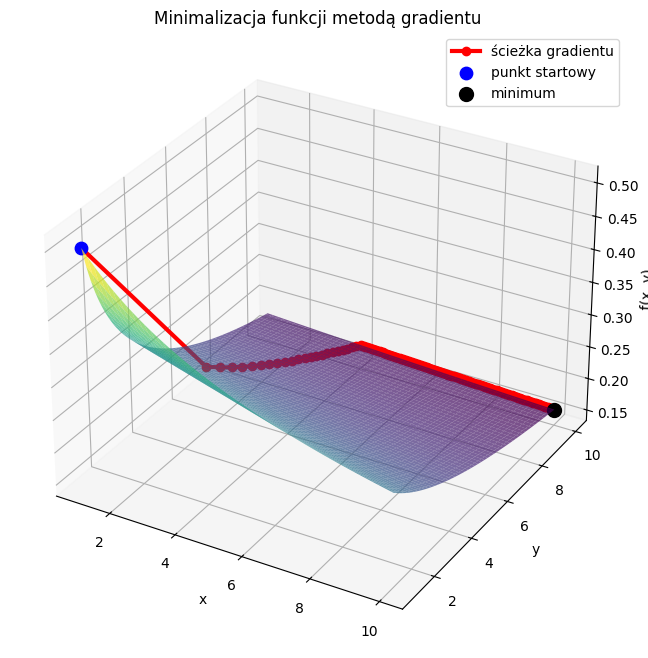

In [33]:
x = np.linspace(1, 10, 100)
y = np.linspace(1, 10, 100)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.7, cmap='viridis')

ax.plot(
    x_history,
    y_history,
    f_history,
    color='red',
    marker='o',
    linewidth=3,
    label='ścieżka gradientu'
)

ax.scatter(
    x_history[0],
    y_history[0],
    f_history[0],
    color='blue',
    s=80,
    label='punkt startowy'
)

ax.scatter(
    x_history[-1],
    y_history[-1],
    f_history[-1],
    color='black',
    s=100,
    label='minimum'
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title("Minimalizacja funkcji metodą gradientu")
ax.legend()

plt.show()

## **Zadanie 2.**

In [34]:
import numpy as np

nn_architecture = [
    {"input_dim": 2, "output_dim": 2, "activation": "sigmoid"},
    {"input_dim": 2, "output_dim": 1, "activation": "elu"}
]


def init_layers(nn_architecture, seed=99):
    np.random.seed(seed)
    params_values = {}

    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1

        layer_input_size = layer["input_dim"]
        layer_output_size = layer["output_dim"]

        params_values["W" + str(layer_idx)] = np.random.randn(
            layer_output_size,
            layer_input_size
        ) * 0.1

        params_values["b" + str(layer_idx)] = np.random.randn(
            layer_output_size,
            1
        ) * 0.1

    return params_values


def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))


def elu(Z, alpha=1):
    return np.where(Z > 0, Z, alpha * (np.exp(Z) - 1))


def sigmoid_backward(dA, Z):
    sig = sigmoid(Z)
    return dA * sig * (1 - sig)


def elu_backward(dA, Z, alpha=1):
    derivative = np.where(Z > 0, 1, alpha * np.exp(Z))
    return dA * derivative


def single_layer_forward_propagation(A_prev, W_curr, b_curr, activation):
    Z_curr = np.dot(W_curr, A_prev) + b_curr

    if activation == "sigmoid":
        activation_func = sigmoid
    elif activation == "elu":
        activation_func = elu
    else:
        raise Exception("Nieobsługiwana funkcja aktywacji")

    A_curr = activation_func(Z_curr)

    return A_curr, Z_curr


def full_forward_propagation(X, params_values, nn_architecture):
    memory = {}
    A_curr = X

    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1

        A_prev = A_curr

        activ_function_curr = layer["activation"]
        W_curr = params_values["W" + str(layer_idx)]
        b_curr = params_values["b" + str(layer_idx)]

        A_curr, Z_curr = single_layer_forward_propagation(
            A_prev,
            W_curr,
            b_curr,
            activ_function_curr
        )

        memory["A" + str(idx)] = A_prev
        memory["Z" + str(layer_idx)] = Z_curr

    return A_curr, memory


def get_cost_value(Y_hat, Y):
    m = Y.shape[1]
    cost = np.sum((Y_hat - Y) ** 2) / m
    return np.squeeze(cost)


def single_layer_backward_propagation(
    dA_curr,
    W_curr,
    b_curr,
    Z_curr,
    A_prev,
    activation
):
    m = A_prev.shape[1]

    if activation == "sigmoid":
        backward_activation_func = sigmoid_backward
    elif activation == "elu":
        backward_activation_func = elu_backward
    else:
        raise Exception("Nieobsługiwana funkcja aktywacji")

    dZ_curr = backward_activation_func(dA_curr, Z_curr)

    dW_curr = np.dot(dZ_curr, A_prev.T) / m
    db_curr = np.sum(dZ_curr, axis=1, keepdims=True) / m
    dA_prev = np.dot(W_curr.T, dZ_curr)

    return dA_prev, dW_curr, db_curr


def full_backward_propagation(Y_hat, Y, memory, params_values, nn_architecture):
    grads_values = {}

    Y = Y.reshape(Y_hat.shape)

    dA_prev = 2 * (Y_hat - Y)

    for layer_idx_prev, layer in reversed(list(enumerate(nn_architecture))):
        layer_idx_curr = layer_idx_prev + 1

        activ_function_curr = layer["activation"]

        dA_curr = dA_prev

        A_prev = memory["A" + str(layer_idx_prev)]
        Z_curr = memory["Z" + str(layer_idx_curr)]
        W_curr = params_values["W" + str(layer_idx_curr)]
        b_curr = params_values["b" + str(layer_idx_curr)]

        dA_prev, dW_curr, db_curr = single_layer_backward_propagation(
            dA_curr,
            W_curr,
            b_curr,
            Z_curr,
            A_prev,
            activ_function_curr
        )

        grads_values["dW" + str(layer_idx_curr)] = dW_curr
        grads_values["db" + str(layer_idx_curr)] = db_curr

    return grads_values

X = np.array([
    [1, 2, 3, 4],
    [2, 3, 4, 5]
], dtype=float)

Y = np.array([
    [1, 0, 1, 0]
], dtype=float)


In [35]:
params_values = init_layers(nn_architecture, seed=99)

Y_hat, memory = full_forward_propagation(
    X,
    params_values,
    nn_architecture
)

cost = get_cost_value(Y_hat, Y)

grads_values = full_backward_propagation(
    Y_hat,
    Y,
    memory,
    params_values,
    nn_architecture
)

print("Wynik sieci Y_hat:")
print(Y_hat)

print("\nWartość funkcji kosztu:")
print(cost)

print("\nGradienty:")
for key, value in grads_values.items():
    print(key)
    print(value)
    print()

Wynik sieci Y_hat:
[[0.08074683 0.08737909 0.09372191 0.09970242]]

Wartość funkcji kosztu:
0.4209855127705696

Gradienty:
dW2
[[-0.51841482 -0.49546427]]

db2
[[-0.81922487]]

dW1
[[-0.02607805 -0.04034814]
 [-0.02962189 -0.04570254]]

db1
[[-0.01427009]
 [-0.01608065]]

